In [27]:
import mne
import os
import pandas as pd
import numpy as np
import sys
sys.path.append("../Preprocessing")
from preprocessingPipeline import simplePipeline
from convertTUHtoBIDS import CHANNELS_TO_KEEP
from defusedxml import ElementTree

In [10]:
raw_epoch = mne.read_epochs("/home/azureuser/mycontainer/TUEV_Processed/train/aaaaaaar_00000001_epo.fif", preload=True, verbose=False)
annotations_per_epoch = raw_epoch.get_annotations_per_epoch()
raw_data = raw_epoch.get_data(copy=True)
print(raw_data.shape)
len(annotations_per_epoch)
for idx, annotations in enumerate(annotations_per_epoch):
	print(idx, annotations)
	descriptions = [int(annotation[2]) for annotation in annotations]
	if len(set(descriptions)) > 1:
		print(set(descriptions))

(26, 19, 7680)
0 [(4.699999809265137, 1.0, '5'), (4.699999809265137, 1.0, '5'), (4.699999809265137, 1.0, '5'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '5'), (4.800000190734863, 1.0, '5'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.800000190734863, 1.0, '6'), (4.900000095367432, 1.0, '5'), (5.699999809265137, 1.0, '5'), (5.699999809265137, 1.0, '5'), (5.699999809265137, 1.0, '5'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '5'), (5.800000190734863, 1.0, '5'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1.0, '6'), (5.800000190734863, 1

In [21]:
raw_eeg_pd = pd.read_csv("/home/azureuser/mycontainer/MOBI/SL08-T03/eeg.txt", delimiter="\t", skiprows=1, header=None)
raw_eeg_impedances_pd = pd.read_csv("/home/azureuser/mycontainer/MOBI/SL08-T03/impedances-before.txt", delimiter="\t", skiprows=20)
raw_conductor_pd = pd.read_csv("/home/azureuser/mycontainer/MOBI/SL08-T03/conductor.txt", delimiter="\t", skiprows=2, header=None)

In [14]:
print(raw_eeg_pd.head())

      0       1       2       3       4       5       6       7       8   \
0  0.141     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1  0.149     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2  0.159  1957.3  1767.6  1953.9  1574.4  1936.5  1192.6  2018.9  1920.8   
3  0.170  1953.7  1764.5  1952.0  1571.4  1935.0  1185.2  2024.8  1924.2   
4  0.180  1957.3  1767.6  1953.9  1574.4  1936.5  1192.6  2018.9  1920.8   

       9   ...      56      57      58      59      60      61      62  \
0     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1     0.0  ...     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2  2039.2  ...  1949.6  1942.8  1706.4  2107.0  1903.4  1994.2  1918.2   
3  2036.6  ...  1947.0  1943.3  1704.2  2100.7  1907.1  1996.1  1920.0   
4  2039.2  ...  1949.6  1942.8  1706.4  2107.0  1903.4  1994.2  1918.2   

       63      64  65  
0     0.0     0.0 NaN  
1     0.0     0.0 NaN  
2  1968.6  1934.9 NaN  
3 

In [18]:
print(raw_eeg_impedances_pd.head())

             Phys. Chn.              Name  Electrode Label / Set No.  \
# 1                 Fp1             1 / 1                         48   
# 2                 Fp2             2 / 1                         54   
# 3                  F7             3 / 1                         25   
# 4                  F3             4 / 1                         27   
# 5                  Fz             5 / 1                         25   

              Impedance [kOhm]  
# 1                        NaN  
# 2                        NaN  
# 3                        NaN  
# 4                        NaN  
# 5                        NaN  


In [22]:
print(raw_conductor_pd.head())

         0   1
0    0.151  11
1    1.010  17
2    7.075  11
3  119.902  10
4  120.003   8


In [89]:
def safe_montage_creation(filename):
    FID_NAME_MAP = {"Nasion": "nasion", "RPA": "rpa", "LPA": "lpa"}
    et = ElementTree.parse(filename)
    sensors = et.find("CapTrakElectrodeList")
    fids, dig_ch_pos = dict(), dict()

    for s in sensors:
        name = s.find("Name").text

        is_fid = name in FID_NAME_MAP
        coordinates = 1e-3 * np.array(
            [float(s.find("X").text), float(s.find("Y").text), float(s.find("Z").text)]
        )

        # Fiducials
        if is_fid:
            fids[FID_NAME_MAP[name]] = coordinates
        # EEG Channels
        else:
            dig_ch_pos[name] = coordinates

    
        montage = mne.channels.make_dig_montage(ch_pos=dig_ch_pos, coord_frame="unknown", nasion=fids.get("nasion", None), lpa=fids.get("lpa", None), rpa=fids.get("rpa", None))

    excluded_sensors = et.find("ExcludedElectrodes")
    to_exclude = []
    for s in excluded_sensors:
        name = s.text
        to_exclude.append(name)

    return montage, to_exclude

In [90]:
montage, to_exclude = safe_montage_creation("/home/azureuser/mycontainer/MOBI/SL08-T03/digitizer.bvct")
print(to_exclude)

['FT10', 'FT9', 'TP10', 'TP9']


In [50]:
names=["GHR", "GKR", "GAR", "GHL", "GKL", "GAL", "PHR", "PKR", "PAR", "PHL", "PKL", "PAL"]

In [52]:
joints = pd.read_csv("/home/azureuser/mycontainer/MOBI/SL08-T03/joints.txt", delimiter="\t", skiprows=2, header=None)

In [53]:
print(joints.head())

      0      1     2     3     4      5     6       7      8       9       10  \
0  0.141  3.015 -1.26 -1.26  2.52  0.405  0.27   0.418 -3.724 -13.841  14.859   
1  0.149  3.015 -1.26 -1.26  2.52  0.405  0.27   0.403 -3.705 -13.806  15.069   
2  0.159  3.015 -1.26 -1.26  2.52  0.405  0.27   9.409 -3.344  -8.214  24.226   
3  0.170  3.015 -1.26 -1.26  2.52  0.405  0.27  15.613 -2.202  -6.592  29.386   
4  0.180  3.015 -1.26 -1.26  2.52  0.405  0.27  18.553 -0.389  -8.464  30.215   

      11     12  13  
0 -2.996 -0.205 NaN  
1 -3.032 -0.177 NaN  
2 -3.410 -1.490 NaN  
3 -3.997  0.025 NaN  
4 -4.371  0.382 NaN  


In [133]:
joints_df = joints.iloc[:, 1:7]
joints_df.columns = ["GHR", "GKR", "GAR", "GHL", "GKL", "GAL"]
print(joints_df.head())
print(joints_df.shape)

     GHR   GKR   GAR   GHL    GKL   GAL
0  3.015 -1.26 -1.26  2.52  0.405  0.27
1  3.015 -1.26 -1.26  2.52  0.405  0.27
2  3.015 -1.26 -1.26  2.52  0.405  0.27
3  3.015 -1.26 -1.26  2.52  0.405  0.27
4  3.015 -1.26 -1.26  2.52  0.405  0.27
(132337, 6)


In [111]:
ch_names = list(raw_eeg_impedances_pd['Phys. Chn.'].to_numpy())
ch_names = [ch_name.strip() for ch_name in ch_names][:-2]
print(ch_names)
channels_to_drop = [ch_name for ch_name in ch_names if ch_name not in CHANNELS_TO_KEEP]
channels_to_drop.remove("C5")
channels_to_drop.remove("C6")
channels_to_drop.remove("P5")
channels_to_drop.remove("P6")
chtypes = []
for ch_name in ch_names:
	if ch_name in ['FT9', "FT10", "TP9", "TP10"]:
		chtypes.append("eog")
	else:
		chtypes.append("eeg")

['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FT9', 'FT7', 'FC3', 'FC4', 'FT8', 'FT10', 'C5', 'C1', 'C2', 'C6', 'TP7', 'CP3', 'CPz', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO3', 'POz', 'PO4', 'PO8']


In [112]:
info = mne.create_info(ch_names=ch_names, sfreq=100, ch_types=chtypes)
data = raw_eeg_pd.iloc[:, 1:65].to_numpy()
data = data.T
print(data.shape)
print(data)

(64, 132337)
[[   0.     0.  1957.3 ... 1943.4 1932.9 1949.1]
 [   0.     0.  1767.6 ... 1763.4 1747.5 1759.8]
 [   0.     0.  1953.9 ... 1935.8 1936.3 1962.7]
 ...
 [   0.     0.  1918.2 ... 1882.2 1882.3 1876.4]
 [   0.     0.  1968.6 ... 1944.7 1943.8 1935.5]
 [   0.     0.  1934.9 ... 1921.8 1921.6 1913.3]]


In [113]:
raw = mne.io.RawArray(data, info)

Creating RawArray with float64 data, n_channels=64, n_times=132337
    Range : 0 ... 132336 =      0.000 ...  1323.360 secs
Ready.


In [114]:
print(montage)

<DigMontage | 0 extras (headshape), 0 HPIs, 1 fiducials, 62 channels>


In [115]:
raw.drop_channels(channels_to_drop)

<RawArray | 19 x 132337 (1323.4 s), ~19.2 MB, data loaded>

In [117]:
raw.set_montage(montage)

/tmp/ipykernel_4841/546628248.py:1: RuntimeWarning: Fiducial point lpa not found, assuming identity unknown to head transformation
  raw.set_montage(montage)


<RawArray | 19 x 132337 (1323.4 s), ~19.2 MB, data loaded>

In [119]:
mapping = {
	"C5": "T3",
	"C6": "T4",
	"P5": "T5",
	"P6": "T6"
}

In [ ]:
mne.rename_channels(raw.info, mapping)

In [ ]:
assert set(raw.info["ch_names"]) == CHANNELS_TO_KEEP, f"{raw.info['ch_names']} != {CHANNELS_TO_KEEP}" 

TypeError: set.remove() takes exactly one argument (0 given)

In [126]:
for ch in raw.info["ch_names"]:
	if ch not in CHANNELS_TO_KEEP:
		print(ch)

In [129]:
for ch in CHANNELS_TO_KEEP:
	if ch not in raw.info["ch_names"]:
		print(ch)

A2
A1


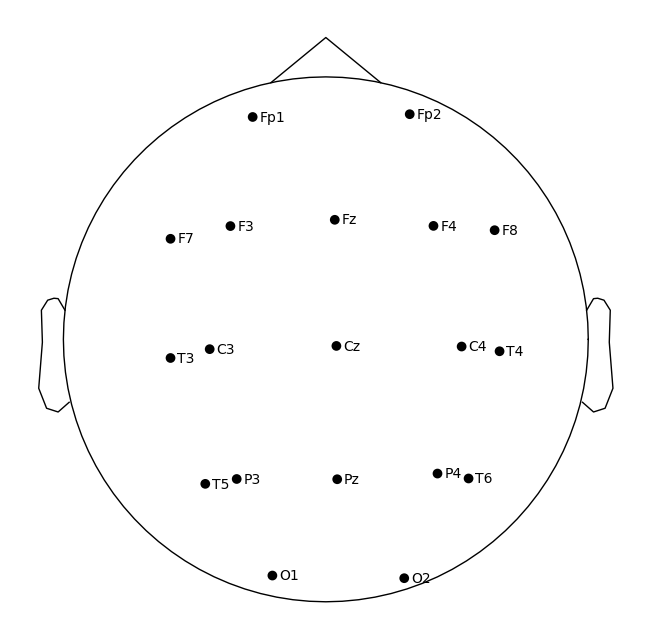

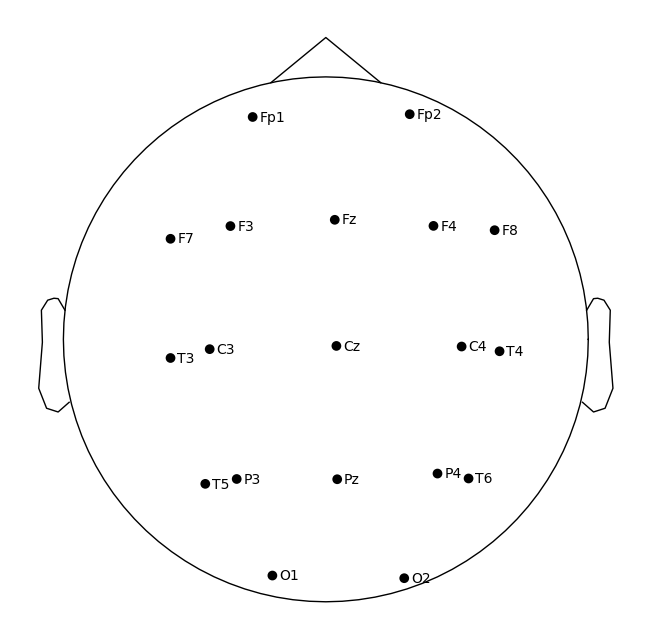

In [130]:
mne.viz.plot_sensors(raw.info, show_names=True)

/tmp/ipykernel_4841/988898452.py:1: RuntimeWarning: Fiducial point lpa not found, assuming identity unknown to head transformation
  mne.viz.plot_montage(montage)


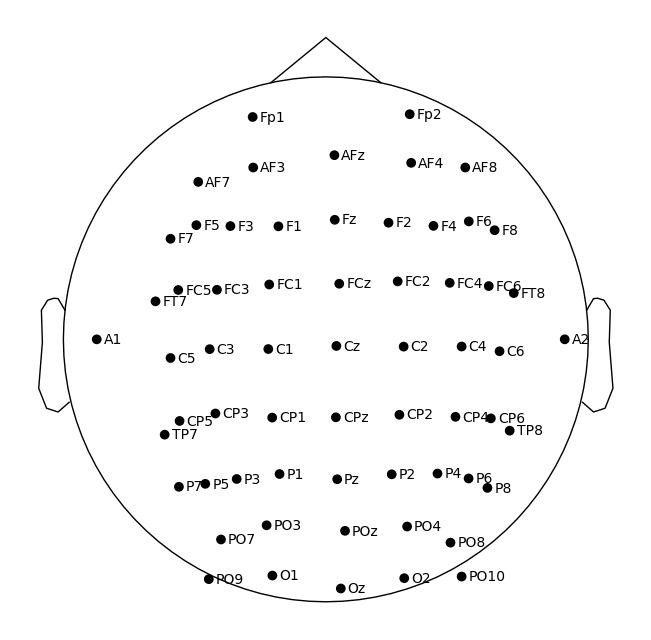

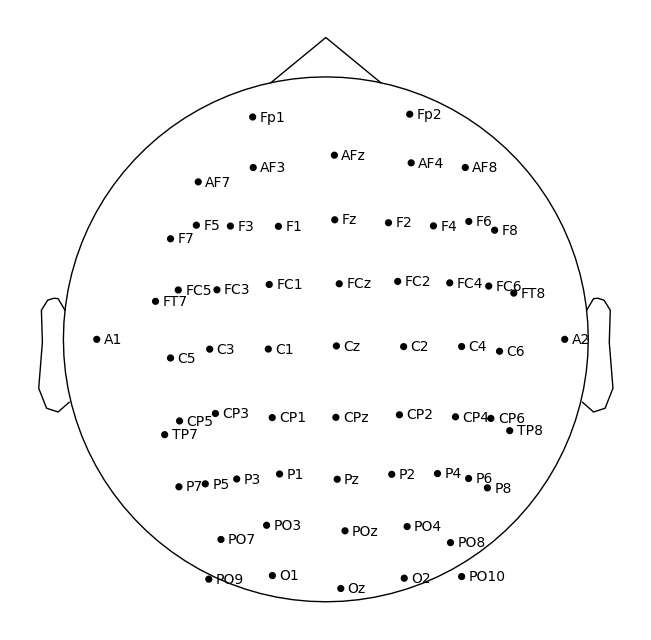

In [131]:
mne.viz.plot_montage(montage)